In [2]:
import matplotlib.pyplot as plt
import sys
sys.path.append('../../Codes/library/')

from funcs import*

plt.rcParams['text.usetex'] = True
Text_files_path = '/Users/robertomorantovar/Dropbox/Research/Immune_system/'
output_plot = '/Users/robertomorantovar/Dropbox/My_Documents/Science/Projects/Immune_System/_Repository/Figures/exponential_proofreading/antigen_presentation/'
os.makedirs(output_plot, exist_ok=True)

%autosave 60

Autosaving every 60 seconds


In [3]:
def simulate_exact(alpha, sigma, lam, delta, x0, T=None, Theta=None, rng=np.random):
    t = 0.0
    n = x0
    traj = [(t, n)]
    while True:
        if T is not None and t >= T: break
        if Theta is not None and n >= Theta: break

        # birth clock (NHPP)
        r = rng.exponential(1.0)
        tau_b = (1.0/lam) * np.log(1.0 + (lam/alpha**sigma)*r*np.exp(-lam*t))

        # death clock
        if n > 0:
            tau_d = rng.exponential(1.0/(delta*n))
        else:
            tau_d = np.inf

        if tau_b < tau_d:
            t += tau_b
            n += 1
        else:
            t += tau_d
            n -= 1

        traj.append((t, n))

    return traj  # also return division time if Theta used

In [4]:
def simulate_tauleap(alpha, lam, delta, x0, T=None, Theta=None,
                     eps=0.05, eta=0.2, dt_max=np.inf, rng=np.random):
    t = 0.0
    n = x0
    traj = [(t, n)]
    while True:
        if T is not None and t >= T: break
        if Theta is not None and n >= Theta: break

        dt1 = (1.0/lam) * np.log(1.0 + eps)         # control exp-growth change
        dt2 = eta / delta                            # control death fraction
        dt  = min(dt1, dt2, dt_max)

        # don't step past the end time
        if T is not None:
            dt = min(dt, T - t)
            if dt <= 0: break

        # births: Poisson with integrated intensity
        m_b = (alpha/lam) * (np.exp(lam*(t+dt)) - np.exp(lam*t))
        B = rng.poisson(m_b)

        # deaths: Binomial (nonnegative guarantee)
        p = 1.0 - np.exp(-delta*dt)
        D = rng.binomial(n, p) if n > 0 else 0

        n = n + B - D
        t = t + dt
        traj.append((t, n))

    return traj

In [66]:
beta = 2.2
data_simulation = defaultdict(list)
for theta in [1.0, 5.0]:
    for sigma in [1.0, 2.0, 3.0]:
        times = np.linspace(10, 20, 100)
        Ks = np.logspace(0, 1.5, 10)
        for i_ens in range(1000):
            for K, omega in zip(Ks, Ks**beta):
                ts_act = []
                for n in range(int(1)):
                    traj1 = simulate_exact(alpha=1/K, sigma = sigma, lam=1, delta=0.1, x0=0, T=20, Theta=theta)
                    ts_act.append(traj1[-1][0])
                    # traj2 = simulate_tauleap(alpha=alpha, lam=1, delta=0.01, x0=0, T=20, Theta=theta)
                data_simulation['beta'].append(beta)
                data_simulation['sigma'].append(sigma)
                data_simulation['theta'].append(theta)
                data_simulation['K'].append(K)
                data_simulation['N0'].append(omega)
                data_simulation['t_act_mean'].append(np.mean(ts_act))
                data_simulation['t_act_min'].append(np.min(ts_act))

data_simulation_df = pd.DataFrame(data_simulation)
result = (
    data_simulation_df.groupby(["sigma", "theta", "K", 'N0'])[["t_act_mean", "t_act_min"]]
    .mean()
    .reset_index()
)


In [67]:
result

,sigma,theta,K,N0,t_act_mean,t_act_min
0,1.0,1.0,1.000000,1.000000,0.579921,0.579921
1,1.0,1.0,1.467799,2.326305,0.763184,0.763184
2,1.0,1.0,2.154435,5.411695,0.969689,0.969689
3,1.0,1.0,3.162278,12.589254,1.165256,1.165256
4,1.0,1.0,4.641589,29.286446,1.446570,1.446570
5,1.0,1.0,6.812921,68.129207,1.733136,1.733136
6,1.0,1.0,10.000000,158.489319,2.033143,2.033143
7,1.0,1.0,14.677993,368.694506,2.298356,2.298356
8,1.0,1.0,21.544347,857.695899,2.651391,2.651391
9,1.0,1.0,31.622777,1995.262315,2.998595,2.998595


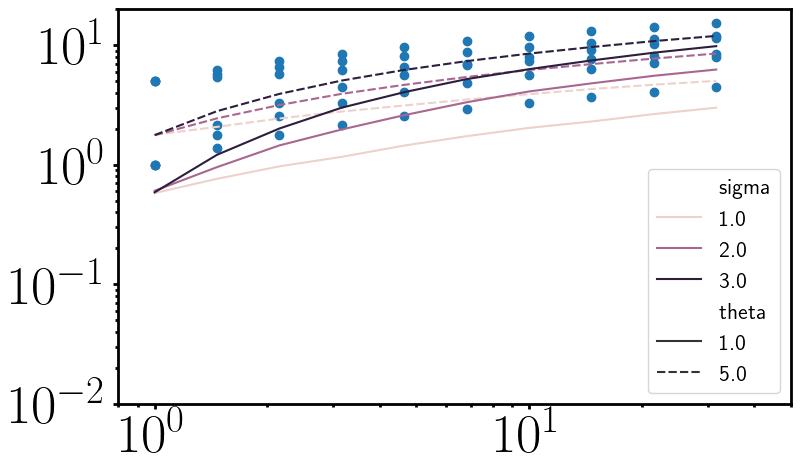

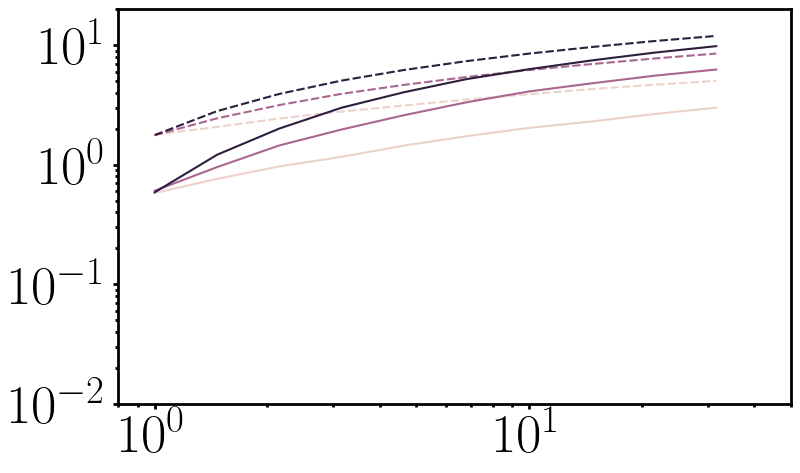

In [70]:
fig_mean, ax_mean = plt.subplots(figsize=(5*1.62,5), gridspec_kw={'left':0.12, 'right':.95, 'bottom':.15, 'top': 0.94})
sns.lineplot(data = result, x = 'K', y = 't_act_mean', hue = 'sigma', style = 'theta', ax=ax_mean)
ax_mean.scatter(result['K'], result['sigma']*np.log(result['K']) + result['theta'])
my_plot_layout(ax=ax_mean, ticks_labelsize= 40, x_fontsize=30, y_fontsize=30)
ax_mean.set_xscale('log')
ax_mean.set_yscale('log')
ax_mean.set_ylim(bottom=1e-2, top = 20)
ax_mean.set_xlim(left=0.8, right=50)
ax_mean.legend(loc = 4, fontsize = 16)
fig_mean.savefig(output_plot + 'times_mean.pdf')

fig_min, ax_min = plt.subplots(figsize=(5*1.62,5), gridspec_kw={'left':0.12, 'right':.95, 'bottom':.15, 'top': 0.94})
sns.lineplot(data = result, x = 'K', y = 't_act_min', hue = 'sigma', style = 'theta', ax=ax_min, legend=False)
my_plot_layout(ax=ax_min, ticks_labelsize= 40, x_fontsize=30, y_fontsize=30)
ax_min.set_xscale('log')
ax_min.set_yscale('log')
ax_min.set_ylim(bottom=1e-2, top = 20)
ax_min.set_xlim(left=0.8, right=50)
# ax_min.legend(loc = 2)
fig_min.savefig(output_plot + 'times_min.pdf')
